# **WEEK 4:TASK 1 -LINEAR REGRESSION**

For task 1 i will use a Kaggle Housing Dataset.The project focuses on building a supervised machine learning model to predict a continous numerical value which is the sale price based on the house characteristics.The model will be trained and then evaluated using the Root Mean Square Error(RMSE) to measure how close the prediction prices are to the actual prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [4]:
df=pd.read_csv("Housing.csv")

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.shape

(545, 13)

In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [11]:
df.duplicated().sum()

np.int64(0)

# **EXPLORATORY DATA ANALYSIS (EDA)**
EDA is an important step in the Machine Learning process.It involves examining and summarizing the main characteristics of a dataset before building a predictive model.

In [12]:
#Summary Statistics
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# Correlation Analysis

Correlation Analysis is used yo understand the relationship between numerical variables in the dataset. It helps identify which features have stronger relationships with house prices and can also reveal possible multicolinearity between predictor variables.

In [13]:
df.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


## One-Hot Encoding for Categorical Variables

Many machine learning algorithms require numerical input. One-hot encoding is a technique used to convert categorical variables into a numerical format that can be easily understood by these algorithms. Each category is transformed into a new binary column (0 or 1), indicating the presence or absence of that category.

In [15]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its shape
display(df_encoded.head())
print(f"Shape of DataFrame after one-hot encoding: {df_encoded.shape}")

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Shape of DataFrame after one-hot encoding: (545, 14)


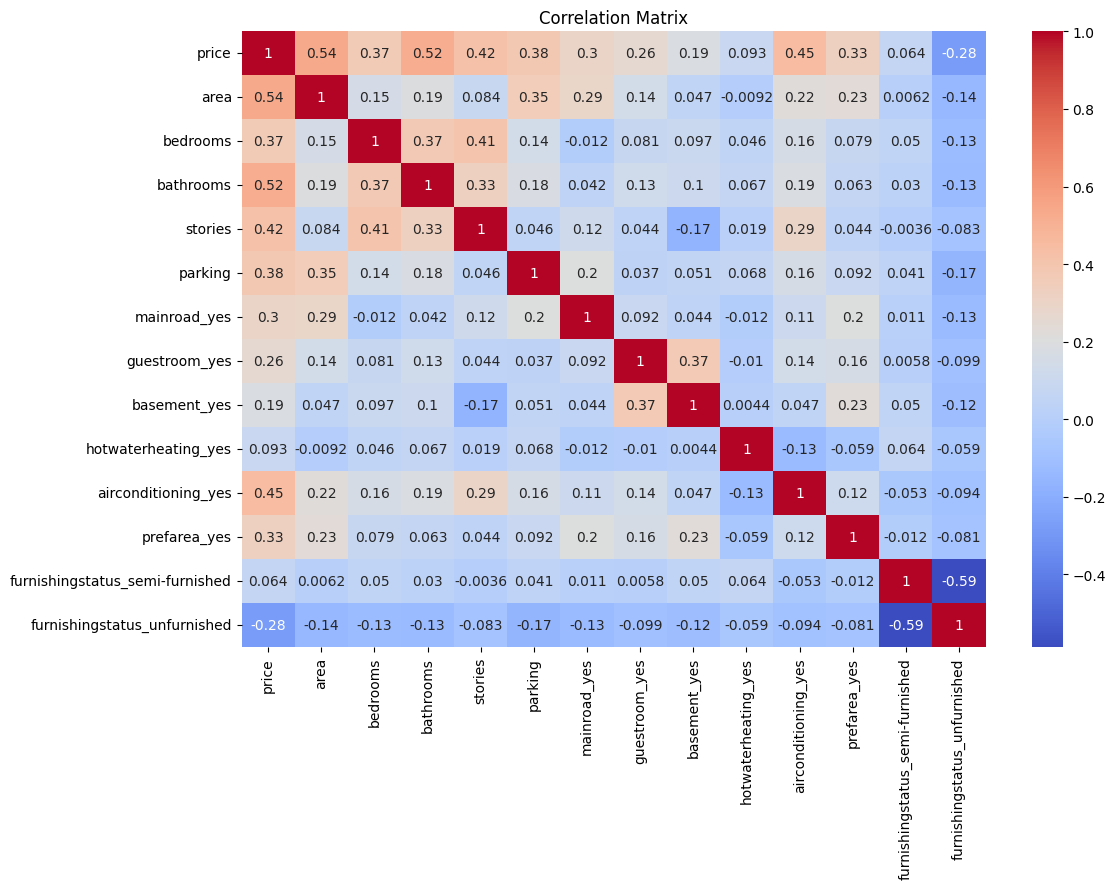

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# **FEATURE SELECTION**

Feature selection is the process of identifying the input variables that will be used by a machine learning model to make predictions .In supervised learning, the dataset is divided into features (x) and a target variable (y).The features (x) represent the independent variables that provide information about the houses, while the target variable (y) represents the outcome that the model is trained to predict.

**Features (x):**All house characteristics used to predict the house price,excluding the price column.

**Target (y):**the 'price'variable,which represents the selling price of the houses.

The target variable is separated from the features to prevent data leakage,ensuring that the model learns patterns from the input variables and predictsthe price based on unseen data.

In [19]:
df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)
df=df.astype(int)
x=df.drop('price',axis=1)
y=df['price']
#

In [20]:
x.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [21]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


# **TRAIN-TEST SPLIT**

Before training the ML model, the dataset is divided into two separate parts: a training set and a testing set.
The training set is used to teach the model by allowing it to learn patterns and relationships between the input features and the target variable. The testing set is used to evaluate how well the training model performs on new, unseen data.Splitting the dataset helps measure the model's ability to generalize and prevents evaluating the model only on data it has already seen.

**80%:**Training set

**20%:**Testing set

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#

In [23]:
x_train.shape,x_test.shape

((436, 13), (109, 13))

In [24]:
y_train.shape,y_test.shape

((436,), (109,))

# **TRAINING THE LINEAR REGRESSION MODEL**

Linear regression is a supervised machine learning algorithm used to predict continuous numerical values.

In this project, Linear Regression is used to learn the relationship between house characteristics (features) and the house selling price (target variable).

The model estimates the relationship between the independent variables and the target variable by finding the best-fitting line that minimizes the difference between actual prices and predicted prices.

In [25]:
from sklearn.linear_model import LinearRegression
#Create the model
model=LinearRegression()
#Train the model
model.fit(x_train,y_train)

LinearRegression()

# **PREDICTIONS**
After training the Linear Regression model,the model is used to predict house prices using the testing dataset.The testing data contains houses that the model has not seen before, allowing us to evaluate how well it can make predictions on unseen observations.

In [26]:
y_pred=model.predict(x_test)


In [29]:
y_pred[:5].round(2)

array([5164653.9 , 7224722.3 , 3109863.24, 4612075.33, 3294646.26])

# **MODEL EVALUATION**
To evaluate the performance of the Linear Regression model, Root Mean Squared Error (RMSE) will be used.RMSE measures the average difference between actual house prices and the prices predicted by the model.A lower RMSE value indicates that the model's predictions are closer to the actual values, meaning the model is performing well.

In [31]:
from sklearn.metrics import mean_squared_error
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f"RMSE: {rmse:.2f}")

RMSE: 1324506.96


# **CONCLUSION**

This project succesfully demonstrated the process of building a machine learning model for predicting house prices using Linear Regression.The dataset was explored and prepared through data cleaning, EDA, and preprocessing of categorial variables .Feature selection and train-test splitting were performed to prepare the data for modelling.The Linear  Regression model was trained using the training dataset and used to predict house prices on unseen testing  data.Model performance was evaluated using Root Mean Squared Error (RMSE), where a lower value indicates that the model's predictions are closer to the actual house prices.

Through this project I gained practical experiencein the complete machine learning workflow,including data preparation, model training, prediction, and evaluation.The project also highligted the importance of understanding the dataset and performing proper preprocessing before applying machine learning algorithms.Further improvements could  include testing other regression algorithms,performing additional feature engineering, and applying techniques to address relationships between variables that may affect model performance.